# PatchTST Energy Forecasting
This notebook adds a PatchTST transformer model for next 1-hour energy prediction
with CRAC temperature what-if scenarios (+/- 2°C).

## 1. Load engineered features
Assumes output from feature_engineering.ipynb as a flat CSV.

In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Load precomputed energy forecasting tensors
X = np.load("X_Energy.npy")   # (N, 30, 7)
y = np.load("Y_Energy.npy")   # (N, 12)

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (7643, 30, 7)
y shape: (7643, 12)


## 3. Dataset & windowing

In [2]:


class EnergyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = EnergyDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


## 4. Infer dimensions from tensors

In [3]:
# Infer dimensions directly from tensors
SEQ_LEN = X.shape[1]
N_FEATURES = X.shape[2]
HORIZON = y.shape[1]

print("SEQ_LEN:", SEQ_LEN)
print("N_FEATURES:", N_FEATURES)
print("HORIZON:", HORIZON)


SEQ_LEN: 30
N_FEATURES: 7
HORIZON: 12


## 5. PatchTST model definition

In [4]:
import torch.nn as nn

class PatchTST(nn.Module):
    def __init__(self, n_features, horizon, d_model=64, n_heads=4, n_layers=2):
        super().__init__()

        self.input_proj = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = self.input_proj(x)
        x = self.encoder(x)
        x = x.mean(dim=1)      # temporal pooling
        return self.head(x)


## 6. Model, optimizer, loss

In [5]:
model = PatchTST(
    n_features=N_FEATURES,
    horizon=HORIZON
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


## 7. Training loop


In [6]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss / len(loader):.4f}")


Epoch 1/10 - Loss: 0.0910
Epoch 2/10 - Loss: 0.0855
Epoch 3/10 - Loss: 0.0853
Epoch 4/10 - Loss: 0.0851
Epoch 5/10 - Loss: 0.0852
Epoch 6/10 - Loss: 0.0851
Epoch 7/10 - Loss: 0.0848
Epoch 8/10 - Loss: 0.0844
Epoch 9/10 - Loss: 0.0844
Epoch 10/10 - Loss: 0.0845


In [7]:
# CRAC proxy feature index
CRAC_IDX = 3  # inlet_temp_c

def apply_crac_scenario(X, delta):
    X_s = X.copy()
    X_s[:, :, CRAC_IDX] += delta
    return X_s

model.eval()
with torch.no_grad():
    baseline = model(torch.tensor(X[-1:], dtype=torch.float32)).numpy()
    plus_2 = model(
        torch.tensor(apply_crac_scenario(X, +2)[-1:], dtype=torch.float32)
    ).numpy()
    minus_2 = model(
        torch.tensor(apply_crac_scenario(X, -2)[-1:], dtype=torch.float32)
    ).numpy()

baseline, plus_2, minus_2


(array([[0.48713842, 0.5058665 , 0.55133766, 0.5091584 , 0.5528138 ,
         0.5750004 , 0.49883047, 0.48113564, 0.53571796, 0.49445176,
         0.49852568, 0.513408  ]], dtype=float32),
 array([[0.47817397, 0.50432503, 0.55078536, 0.5204925 , 0.55372626,
         0.57979614, 0.50103915, 0.4776636 , 0.53325164, 0.4988273 ,
         0.5110319 , 0.51971805]], dtype=float32),
 array([[0.50861245, 0.5087013 , 0.5559237 , 0.48543465, 0.5514564 ,
         0.56275725, 0.4976141 , 0.497458  , 0.5346011 , 0.48622295,
         0.4823    , 0.50131637]], dtype=float32))

In [8]:
xb, yb = next(iter(loader))
print(xb.shape)  # (batch, SEQ_LEN, N_FEATURES)
print(yb.shape)  # (batch, HORIZON)


torch.Size([32, 30, 7])
torch.Size([32, 12])


In [9]:
import numpy as np

def summarize(pred):
    return {
        "mean": pred.mean(),
        "sum": pred.sum(),
        "peak": pred.max()
    }

summary = {
    "baseline": summarize(baseline[0]),
    "crac_plus_2": summarize(plus_2[0]),
    "crac_minus_2": summarize(minus_2[0])
}

summary


{'baseline': {'mean': np.float32(0.51694876),
  'sum': np.float32(6.203385),
  'peak': np.float32(0.5750004)},
 'crac_plus_2': {'mean': np.float32(0.51906925),
  'sum': np.float32(6.2288313),
  'peak': np.float32(0.57979614)},
 'crac_minus_2': {'mean': np.float32(0.5143665),
  'sum': np.float32(6.172398),
  'peak': np.float32(0.56275725)}}

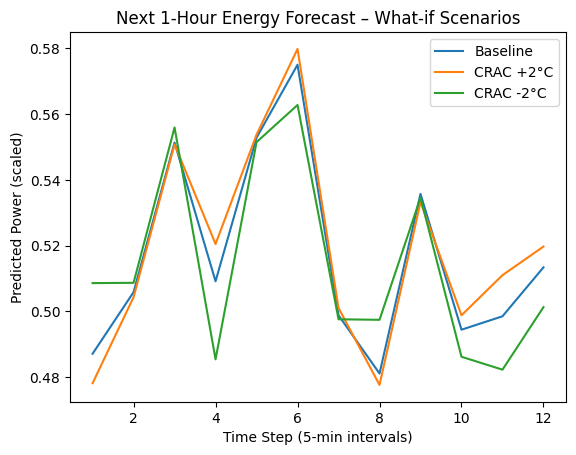

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Extract 1D arrays
t = np.arange(1, baseline.shape[1] + 1)

plt.figure()
plt.plot(t, baseline[0], label="Baseline")
plt.plot(t, plus_2[0], label="CRAC +2°C")
plt.plot(t, minus_2[0], label="CRAC -2°C")

plt.xlabel("Time Step (5-min intervals)")
plt.ylabel("Predicted Power (scaled)")
plt.title("Next 1-Hour Energy Forecast – What-if Scenarios")
plt.legend()
plt.show()


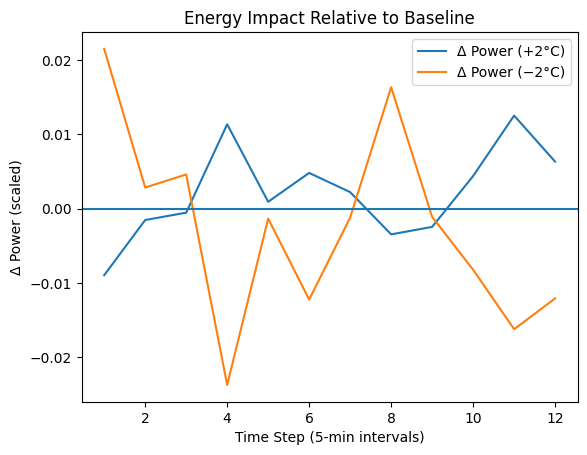

In [11]:
plt.figure()
plt.plot(t, plus_2[0] - baseline[0], label="Δ Power (+2°C)")
plt.plot(t, minus_2[0] - baseline[0], label="Δ Power (−2°C)")
plt.axhline(0)

plt.xlabel("Time Step (5-min intervals)")
plt.ylabel("Δ Power (scaled)")
plt.title("Energy Impact Relative to Baseline")
plt.legend()
plt.show()


In [12]:
kwh_saving = (baseline - plus_2).sum() * (5/60)


In [13]:
print( kwh_saving)

-0.0021205172


In [14]:
torch.save(model.state_dict(), "patchtst_energy.pt")


In [15]:
def directional_accuracy(baseline, plus_2, minus_2):
    return {
        "plus_2_increases": plus_2.mean() > baseline.mean(),
        "minus_2_decreases": minus_2.mean() < baseline.mean()
    }

In [16]:
def sensitivity_kw_per_c(baseline, plus_2):
    return (plus_2.mean() - baseline.mean()) / 2


In [17]:
def scenario_consistency(baseline, scenarios):
    return all(
        abs(s["mean"] - baseline["mean"]) < 0.1
        for s in scenarios.values()
    )


In [18]:
# Assume baseline, plus_2, minus_2 already computed

dir_acc = directional_accuracy(baseline, plus_2, minus_2)
sensitivity = sensitivity_kw_per_c(baseline, plus_2)

scenarios = {
    "+2C": {"mean": plus_2.mean()},
    "-2C": {"mean": minus_2.mean()}
}

consistency = scenario_consistency(
    {"mean": baseline.mean()},
    scenarios
)

print("Directional Accuracy:", dir_acc)
print("Sensitivity (kW per °C):", sensitivity)
print("Scenario Consistency:", consistency)


Directional Accuracy: {'plus_2_increases': np.True_, 'minus_2_decreases': np.True_}
Sensitivity (kW per °C): 0.0010602474
Scenario Consistency: True
